# TQU QML Power Spectrum Analysis

This notebook provides a step-by-step analysis of QML power spectrum estimation for TEB (Temperature-E-B mode) polarization data from TQU simulations.

## 1. Import Required Libraries

In [1]:
import os
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import yaml
from mpi4py import MPI

# Import cosmocore modules
from cosmocore import (
    InputParams,
    do_derivative_step,
    matrix_mult,
    matrix_trace,
    read_maps,
)

# Import qube modules
from qube import Spectra

# Set up plotting style
plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 8)

print("All imports successful!")
print(f"MPI size: {MPI.COMM_WORLD.Get_size()}, rank: {MPI.COMM_WORLD.Get_rank()}")

All imports successful!
MPI size: 1, rank: 0


In [2]:
def configure_plt():
    plt.rc("axes", labelsize=20, linewidth=1.5)
    plt.rc("xtick", direction="in", labelsize=15, top=True)
    plt.rc("ytick", direction="in", labelsize=15, right=True)

    plt.rc("xtick.major", width=1.1, size=5)
    plt.rc("ytick.major", width=1.1, size=5)

    plt.rc("xtick.minor", width=1.1, size=3)
    plt.rc("ytick.minor", width=1.1, size=3)

    plt.rc("lines", linewidth=2)
    plt.rc("legend", frameon=False, fontsize=15)
    plt.rc("figure", dpi=100, autolayout=True, figsize=[10, 7])
    plt.rc("savefig", dpi=300, bbox="tight")


configure_plt()

## 2. Setup Test Parameters and Configuration

In [3]:
QUBE_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))


def resolve_config(config_rel, overrides=None):
    """Anchor YAML paths to qube root so the notebook runs from any cwd."""
    full_path = os.path.join(QUBE_ROOT, config_rel)
    with open(full_path) as f:
        config = yaml.safe_load(f)
    for key, value in config.items():
        if isinstance(value, str):
            clean = value
            while clean.startswith("../"):
                clean = clean[3:]
            if clean.startswith("tests/") or clean.startswith("scripts/"):
                config[key] = os.path.join(QUBE_ROOT, clean)
    if overrides:
        config.update(overrides)
    tmp = tempfile.NamedTemporaryFile(mode="w", suffix=".yaml", delete=False)
    yaml.dump(config, tmp, default_flow_style=False)
    tmp.close()
    return tmp.name

In [4]:
# Set up test configuration paths
local_path = os.path.abspath(os.getcwd())
fields = "TQU"  # Use TQU configuration for debugging
nside = 4
param_file = resolve_config(f"tests/data/nside{nside}/{fields}/config.yaml")

print(f"Local path: {local_path}")
print(f"Parameter file: {param_file}")
print(f"Parameter file exists: {os.path.exists(param_file)}")

# Load parameters
params = InputParams.read_parameter_file(param_file)

# Display key parameters
print("\n=== Key Parameters ===")
print(f"nside: {params.nside}")
print(f"spins: {params.spins}")
print(f"labels: {getattr(params, 'labels', 'Not specified')}")
print(f"physical_labels: {getattr(params, 'physical_labels', 'Not specified')}")
print(f"nspectra: {params.nspectra}")
print(f"lmax: {params.lmax}")
print(f"nsims: {params.nsims}")
print(f"do_cross: {params.do_cross}")
print(f"calibration: {params.calibration}")

Local path: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.qube/notebooks
Parameter file: /tmp/tmpn0dprmnr.yaml
Parameter file exists: True

=== Key Parameters ===
nside: 4
spins: [0, 2]
labels: ['T', 'E', 'B']
physical_labels: ['T', 'Q', 'U']
nspectra: 6
lmax: 8
nsims: 50
do_cross: False
calibration: 1.0


## 3. Initialize Spectra Instance

In [5]:
# Initialize Spectra instance
print("Creating Spectra instance...")
spectra = Spectra(param_file)

# Display MPI and basic info
print(f"MPI rank: {spectra.rank}")
print(f"MPI size: {spectra.size}")
print(f"Parameters loaded: {spectra.params is not None}")
print(f"Fisher instance created: {spectra.fisher_instance is not None}")

# Display initial variable states
print("\n=== Initial Variable States ===")
print(f"maps1: {spectra.maps1}")
print(f"maps2: {spectra.maps2}")
print(f"y: {spectra.qml_results}")
print(f"ynb: {spectra.qml_noise_bias}")
print(f"invfisher: {spectra.invfisher}")

Creating Spectra instance...
2026-05-15 11:08:14 | spectra      | INFO     | Starting Fisher matrix computation...


2026-05-15 11:08:14 | fisher       | INFO     | Starting Fisher matrix analysis pipeline


2026-05-15 11:08:23 | fisher       | INFO     | --------------------------------------------------------------------------------


2026-05-15 11:08:23 | fisher       | INFO     | Fisher matrix computation completed


2026-05-15 11:08:23 | spectra      | INFO     | Fisher matrix computation completed in 9.09 seconds


MPI rank: 0
MPI size: 1
Parameters loaded: True
Fisher instance created: True

=== Initial Variable States ===
maps1: None
maps2: None
y: None
ynb: None
invfisher: None


## 4. Setup Fields and Geometry

In [6]:
# Execute setup_fields() and setup_geometry()
print("=== Setting up fields ===")
spectra.setup_fields()
print("Fields setup completed")

print("\n=== Setting up geometry ===")
spectra.setup_geometry()
print("Geometry setup completed")

# Inspect results
print("\n=== Geometry Results ===")
print(f"nside: {params.nside}")
print(f"Total pixels: {params.nside**2 * 12}")
print(f"npixs type: {type(spectra.npixs)}")
print(f"npixs: {spectra.npixs}")
print(f"n_active: {spectra.collection.n_active}")
print(f"Total pixels: {sum(spectra.collection.n_active)}")

if hasattr(spectra, "pixact") and spectra.pixact is not None:
    print(f"pixact type: {type(spectra.pixact)}")
    print(f"pixact length: {len(spectra.pixact)}")
    for i, pix in enumerate(spectra.pixact):
        print(
            f"  Field {i}: {len(pix) if hasattr(pix, '__len__') else pix} active pixels"
        )

# Check collection and spectra labels
if hasattr(spectra, "collection") and spectra.collection is not None:
    print(f"\nSpectra labels: {spectra.collection.spectra_labels}")
    print(f"Number of spectra: {len(spectra.collection.spectra_labels)}")

    # This is the KEY issue we're investigating
    print('Expected spectra: ["TT", "EE", "BB", "EB", "TE", "TB"]')
    print(f"Actual spectra: {spectra.collection.spectra_labels}")
else:
    print("Collection not available")

=== Setting up fields ===
Fields setup completed

=== Setting up geometry ===
Geometry setup completed

=== Geometry Results ===
nside: 4
Total pixels: 192
npixs type: <class 'list'>
npixs: [192, 192]
n_active: [192, 192, 192]
Total pixels: 576
pixact type: <class 'numpy.ndarray'>
pixact length: 3
  Field 0: 192 active pixels
  Field 1: 192 active pixels
  Field 2: 192 active pixels

Spectra labels: ['TT', 'EE', 'BB', 'EB', 'TE', 'TB']
Number of spectra: 6
Expected spectra: ["TT", "EE", "BB", "EB", "TE", "TB"]
Actual spectra: ['TT', 'EE', 'BB', 'EB', 'TE', 'TB']


## 5. Load Maps Data

In [7]:
# Execute setup_maps() - this follows the exact pattern from spectra.run()
print("=== Loading maps ===")
# Read maps using the core functionality
ntot = sum(spectra.collection.n_active)
print(f"Total active pixels (ntot): {ntot}")

spectra.maps1 = np.empty((ntot, spectra.params.nsims), dtype=np.float64)
read_maps(
    maps=spectra.maps1,
    filename=spectra.params.inputmapfile1,
    pixact=spectra.pixact,
    field_labels=spectra.params.physical_labels,
    calibration=spectra.params.calibration,
)
print("Maps loaded")

print("\n=== Maps1 Info ===")
print(f"maps1 shape: {spectra.maps1.shape}")
print(f"maps1 dtype: {spectra.maps1.dtype}")
print(f"maps1 min/max: {spectra.maps1.min():.3e} / {spectra.maps1.max():.3e}")
print(f"maps1 mean/std: {spectra.maps1.mean():.3e} / {spectra.maps1.std():.3e}")

=== Loading maps ===
Total active pixels (ntot): 576
Maps loaded

=== Maps1 Info ===
maps1 shape: (576, 50)
maps1 dtype: float64
maps1 min/max: -1.256e+02 / 1.265e+02
maps1 mean/std: 1.167e-03 / 2.057e+01


## 6. Load Covariance Matrices

In [8]:
# Load covariance matrices - from spectra.run()
print("=== Loading covariance matrices ===")

ntot = sum(spectra.collection.n_active)
print(f"Total matrix size: {ntot} x {ntot}")

# Load inv_cov1 (inverted covariance matrix)
print(f"Loading inv_cov1 from: {spectra.params.outinvcovmatfile1}")
spectra.inv_cov1 = np.fromfile(spectra.params.outinvcovmatfile1).reshape((ntot, ntot))

# Load noise_cov1 (noise covariance matrix)
print(f"Loading noise_cov1 from: {spectra.params.covmatfile1}")
spectra.noise_cov1 = np.fromfile(spectra.params.covmatfile1).reshape((ntot, ntot))

# Inspect covariance matrices
print("\n=== Covariance Matrix Info ===")
print(f"inv_cov1 shape: {spectra.inv_cov1.shape}")
print(f"inv_cov1 dtype: {spectra.inv_cov1.dtype}")

print(f"\nnoise_cov1 shape: {spectra.noise_cov1.shape}")
print(f"noise_cov1 dtype: {spectra.noise_cov1.dtype}")

=== Loading covariance matrices ===
Total matrix size: 576 x 576
Loading inv_cov1 from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.qube/tests/data/nside4/TQU/invCOV1.bin
Loading noise_cov1 from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.qube/tests/data/nside4/TQU/NCVM1.bin

=== Covariance Matrix Info ===
inv_cov1 shape: (576, 576)
inv_cov1 dtype: float64

noise_cov1 shape: (576, 576)
noise_cov1 dtype: float64


## 7. Setup Cls and Beams

In [9]:
print("=== Setting up Cls ===")
spectra.setup_cls()
print("Cls setup completed")

print("\n=== Setting up beams ===")
spectra.setup_beams()
print("Beams setup completed")

# Inspect the spectra collection
print("\n=== Spectra Collection Info ===")
if hasattr(spectra, "collection") and spectra.collection is not None:
    print(f"Collection type: {type(spectra.collection)}")

    # Get spectra manager info
    if hasattr(spectra.collection, "spectra_manager"):
        mgr = spectra.collection.spectra_manager
        print(f"Spectra labels: {mgr.labels}")
        print(f"Number of spectra: {mgr.n_spectra}")

        # Show reference Cls values
        print("\n=== Reference Cls Values (first few ell) ===")
        if hasattr(mgr, "_cls_dict"):
            for label in mgr.labels:
                if label in mgr._cls_dict:
                    cls_vals = mgr._cls_dict[label]
                    print(f"{label}: {cls_vals[:5]} (ell=2-6)")

    # Get beam manager info
    if hasattr(spectra.collection, "beam_manager"):
        print(f"\nBeam manager available: {spectra.collection.beam_manager is not None}")
else:
    print("Collection not available")

=== Setting up Cls ===


Cls setup completed

=== Setting up beams ===
Beams setup completed

=== Spectra Collection Info ===
Collection type: <class 'cosmocore.fields.FieldCollection'>
Spectra labels: ['TT', 'EE', 'BB', 'EB', 'TE', 'TB']
Number of spectra: 6

=== Reference Cls Values (first few ell) ===
TT: [   0.            0.         1059.36209487  491.52024463  271.50038353] (ell=2-6)
EE: [0.         0.         0.03603948 0.02405363 0.01299698] (ell=2-6)
BB: [0.00000000e+00 0.00000000e+00 1.77551662e-06 1.74076553e-06
 1.69548417e-06] (ell=2-6)
EB: [0. 0. 0. 0. 0.] (ell=2-6)
TE: [0.         0.         2.8793977  1.61880689 0.90506453] (ell=2-6)
TB: [0. 0. 0. 0. 0.] (ell=2-6)

Beam manager available: True


## 8. Compute Smoothing Factors and vecmul

In [10]:
# Set up bins + beam smoothing — mirrors Fisher.run() and Spectra binning stage.
# (Manual replay: a Spectra without a Fisher instance still needs bins and beam_smoothing
# populated for the QML loop below.)
from cosmocore import Bins

delta_ell = getattr(spectra.params, "delta_ell", 1)
bins = Bins.fromdeltal(spectra.params.lmin, spectra.params.lmax, delta_ell)
spectra.set_binning(bins)
print(
    f"Bins: nbins={bins.nbins}, delta_ell={delta_ell}, "
    f"lmin={spectra.params.lmin}, lmax={spectra.params.lmax}"
)

# Build beam_smoothing: per-spectrum, inference range ell=lmin..lmax (ADR 0009).
# Mirrors Fisher.run() (fisher.py:793-809). With beam smoothing internalised into
# derivatives (change_normalization branch), b²_ell is applied inside the binned
# derivative below — no post-hoc vecmul scaling of Fisher.
lmin, lmax = spectra.params.lmin, spectra.params.lmax
n_ell = lmax - lmin + 1
smoothing_dict = spectra.collection.spectra_manager.compute_smoothing_factors(
    spectra.collection.beam_manager
)
spectra.beam_smoothing = np.zeros(spectra.params.nspectra * n_ell, dtype=np.float64)
idx = 0
for label in spectra.collection.spectra_manager.labels:
    spectra.beam_smoothing[idx : idx + n_ell] = smoothing_dict[label][lmin : lmax + 1]
    idx += n_ell

print(f"\nbeam_smoothing shape: {spectra.beam_smoothing.shape}")
for ispec, label in enumerate(spectra.collection.spectra_manager.labels):
    beam = spectra.beam_smoothing[ispec * n_ell : (ispec + 1) * n_ell]
    print(f"  {label}: b_ell first 5 = {beam[:5]}")

Bins: nbins=7, delta_ell=1, lmin=2, lmax=8

beam_smoothing shape: (42,)
  TT: b_ell first 5 = [0.98028946 0.96096704 0.93579436 0.90525283 0.86991455]
  EE: b_ell first 5 = [0.99338634 0.97380603 0.94829738 0.91734821 0.88153825]
  BB: b_ell first 5 = [0.99338634 0.97380603 0.94829738 0.91734821 0.88153825]
  EB: b_ell first 5 = [0.99338634 0.97380603 0.94829738 0.91734821 0.88153825]
  TE: b_ell first 5 = [0.98681618 0.96736524 0.94202513 0.91128045 0.87570712]
  TB: b_ell first 5 = [0.98681618 0.96736524 0.94202513 0.91128045 0.87570712]


## 9. Load and Process Fisher Matrix

In [11]:
# Load and invert Fisher matrix — mirrors Spectra.setup_fisher_inversion()
# (spectra.py:417-452). Fisher on disk is already beam-smoothed (beam window
# functions absorbed into derivatives), so we invert directly — no vecmul scaling.
from cosmocore.basics import matrix_inverse_symm

print(f"Loading Fisher from: {spectra.params.outfilefisher}")
spectra.invfisher = np.loadtxt(spectra.params.outfilefisher)
print(f"Fisher shape: {spectra.invfisher.shape}")
print(f"Fisher diagonal (first 5): {np.diag(spectra.invfisher)[:5]}")

# Keep beam-smoothed Fisher for convolved-mode covariance.
spectra.fisher_normalized = spectra.invfisher.copy()

print("\n=== Inverting Fisher matrix (matrix_inverse_symm) ===")
spectra.invfisher = matrix_inverse_symm(spectra.invfisher)
print(f"invfisher[0,0]: {spectra.invfisher[0, 0]:.3e}")

Loading Fisher from: /home/ggalloni/Projects/GitHub/CosmoForge/src/cosmoforge.qube/tests/data/nside4/TQU/fisher.dat
Fisher shape: (42, 42)
Fisher diagonal (first 5): [3.49204297e-06 2.20735421e-05 9.04120214e-05 2.88906744e-04
 7.93540059e-04]

=== Inverting Fisher matrix (matrix_inverse_symm) ===


invfisher[0,0]: 4.672e+05


## 10. Initialize QML Variables

In [12]:
# Initialize QML variables — mirrors Spectra.setup_qml_computation()
nbins = spectra.bins.nbins
nspectra = spectra.params.nspectra
n_params = nspectra * nbins

spectra.qml_results = np.zeros((spectra.params.nsims, n_params), dtype=np.float64)
spectra.qml_noise_bias = np.zeros(n_params, dtype=np.float64)
print(f"qml_results shape: {spectra.qml_results.shape}")
print(f"qml_noise_bias shape: {spectra.qml_noise_bias.shape}")

# spectra_list (SpectrumKey-keyed) — normally populated by Fisher.compute().
# Manual replay reproduces it here so the QML loop can identify each spectrum.
if getattr(spectra, "spectra_list", None) is None:
    _, spectra.spectra_list = spectra._build_multi_spectrum_inputs()
print(f"spectra_list: {[str(k) for k in spectra.spectra_list]}")

# Working pixel-space dimension
ntot = sum(spectra.collection.n_active)
print(f"ntot (pixel-space dim): {ntot}")

qml_results shape: (50, 42)
qml_noise_bias shape: (42,)
spectra_list: ["SpectrumKey(comp_i=0, comp_j=0, kind=<SpectrumKind.SS: (<Slot.S: ('S', 0)>, <Slot.S: ('S', 0)>)>)", "SpectrumKey(comp_i=1, comp_j=1, kind=<SpectrumKind.GG: (<Slot.G: ('G', 2)>, <Slot.G: ('G', 2)>)>)", "SpectrumKey(comp_i=1, comp_j=1, kind=<SpectrumKind.CC: (<Slot.C: ('C', 2)>, <Slot.C: ('C', 2)>)>)", "SpectrumKey(comp_i=1, comp_j=1, kind=<SpectrumKind.GC: (<Slot.G: ('G', 2)>, <Slot.C: ('C', 2)>)>)", "SpectrumKey(comp_i=0, comp_j=1, kind=<SpectrumKind.SG: (<Slot.S: ('S', 0)>, <Slot.G: ('G', 2)>)>)", "SpectrumKey(comp_i=0, comp_j=1, kind=<SpectrumKind.SC: (<Slot.S: ('S', 0)>, <Slot.C: ('C', 2)>)>)"]
ntot (pixel-space dim): 576


## 11. Main QML Computation Loop

In [13]:
# Main QML loop — mirrors Spectra._compute_qml_spectra_traditional (spectra.py:932+).
# Estimator: q_b = (1/2) y^T binned_deriv y, where y = C^{-1} d.
print("=== Starting main QML computation ===")
start_time = time.time()

# Precompute y = C^{-1} d for all simulations.
weighted_maps1 = matrix_mult(spectra.inv_cov1, spectra.maps1)

# Precompute C^{-1} N C^{-1} for the noise-bias trace.
cinv_noise_cinv = matrix_mult(
    spectra.inv_cov1, matrix_mult(spectra.noise_cov1, spectra.inv_cov1)
)

for param_idx in range(n_params):
    spectrum_idx = param_idx // nbins
    bin_idx = param_idx % nbins

    # Build binned derivative manually: dC^b = sum_{ell in bin} b²_ell dC/dC_ell.
    # For delta_ell=1, each bin contains a single ell. Mirrors the math inside
    # _get_binned_derivative + Fisher's binned-derivative cache.
    bin_lmin = int(spectra.bins.lmins[bin_idx])
    bin_lmax = int(spectra.bins.lmaxs[bin_idx])
    binned_deriv = np.zeros((ntot, ntot), dtype=np.float64, order="F")
    for ell in range(bin_lmin, bin_lmax + 1):
        dC_ell = np.zeros((ntot, ntot), dtype=np.float64, order="F")
        do_derivative_step(
            dC_ell,
            spectrum_idx,
            spectra.npixs,
            spectra.params.spins,
            ell,
            spectra.collection,
        )
        beam = spectra.beam_smoothing[spectrum_idx * n_ell + (ell - lmin)]
        binned_deriv += (
            beam * dC_ell
        )  # beam_smoothing already holds b1*b2 (= b²_ell for autos)

    # q_b = 0.5 y^T binned_deriv y for all sims
    deriv_times_y = matrix_mult(binned_deriv, weighted_maps1)
    q_per_sim = 0.5 * np.sum(weighted_maps1 * deriv_times_y, axis=0)

    # Noise bias: 0.5 Tr[C^{-1} N C^{-1} binned_deriv]
    noise_bias = 0.5 * matrix_trace(cinv_noise_cinv, binned_deriv)
    spectra.qml_noise_bias[param_idx] = noise_bias

    if getattr(spectra.params, "remove_nb", False):
        q_per_sim -= noise_bias

    spectra.qml_results[:, param_idx] = q_per_sim

elapsed = time.time() - start_time
print(f"QML computation completed in {elapsed:.2f} seconds")
print(f"q[0] first 5: {spectra.qml_results[0, :5]}")
print(f"noise_bias first 5: {spectra.qml_noise_bias[:5]}")

=== Starting main QML computation ===


QML computation completed in 0.94 seconds
q[0] first 5: [0.00316097 0.01020781 0.0137457  0.02712483 0.07415335]
noise_bias first 5: [2.18924541e-07 1.00243963e-06 6.01772709e-06 2.46367459e-05
 1.43631352e-04]


## 12. Final Matrix Multiplication

In [14]:
# Final deconvolution — mirrors Spectra._normalize_spectra (spectra.py:1147-1163).
# Equivalent to spectra.get_power_spectra(mode="deconvolved").
print("=== Deconvolving by F^{-1} ===")
power_spectra = spectra.qml_results @ spectra.invfisher
print(f"power_spectra shape: {power_spectra.shape}")
print(f"first 5 values (sim 0): {power_spectra[0, :5]}")

=== Deconvolving by F^{-1} ===
power_spectra shape: (50, 42)
first 5 values (sim 0): [1204.57234397  589.65127492  238.2079115   137.67025435  101.18724531]


## 13. Validate Results and Output

=== Validation and Visualization ===
=== Plotting Original Fiducial Spectra ===


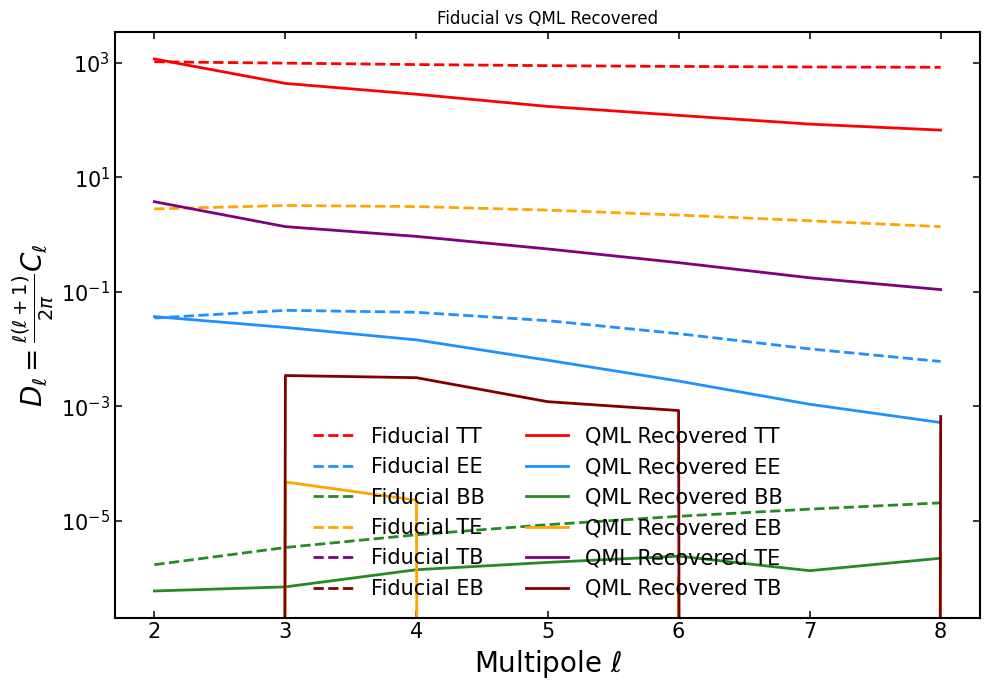

In [15]:
# Validate results and create diagnostic plots
print("=== Validation and Visualization ===")

# Create diagnostic plots
fig, ax = plt.subplots()

# Define colors and labels
colors = ["red", "dodgerblue", "forestgreen", "orange", "purple", "maroon"]
labels = ["TT", "EE", "BB", "TE", "TB", "EB"]

ell = np.arange(2, spectra.params.lmax + 1)
n_ell = len(ell)

# Plot original fiducial spectra (before normalizations and smoothing)
print("=== Plotting Original Fiducial Spectra ===")

# Load the original input spectra from the file used to generate simulations
original_clfid = np.loadtxt(params.inputclfile)
ell = original_clfid[:, 0].astype(int)

# Map original spectrum columns to labels
spectrum_map = {
    "TT": 1,  # Column 1 in original file
    "EE": 2,  # Column 2
    "BB": 3,  # Column 3
    "TE": 4,  # Column 4
    "TB": 5,  # Column 5 (should be zero)
    "EB": 5,  # Column 6 (should be zero) - using same as TB since original has 5 cols
}

# Plot original fiducial spectra
for ispec, spec_label in enumerate(
    ["TT", "EE", "BB", "TE", "TB", "EB"]
):  # Only TT for this case
    if spec_label in spectrum_map and spectrum_map[spec_label] < original_clfid.shape[1]:
        col_idx = spectrum_map[spec_label]
        # Extract the relevant ell range
        ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
        original_spectrum = original_clfid[ell_mask, col_idx]
        ell_plot = ell[ell_mask]

        ax.plot(
            ell_plot,
            original_spectrum,
            "--",
            color=colors[ispec],
            linewidth=2,
            label=f"Fiducial {spec_label}",
            alpha=1,
        )

# Plot computed spectra for comparison
for ispec, spec_label in enumerate(spectra.collection.spectra_labels):
    start_idx = ispec * n_ell
    end_idx = (ispec + 1) * n_ell

    # Plot computed spectrum (average over simulations)
    computed = power_spectra[:, start_idx:end_idx].mean(axis=0)

    ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
    ell_plot = ell[ell_mask]

    ax.plot(
        ell_plot,
        computed,
        color=colors[ispec],
        label=f"QML Recovered {spec_label}",
        alpha=1,
    )

ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell = \frac{{\ell(\ell+1)}}{{2π}}C_\ell$")
ax.set_title("Fiducial vs QML Recovered")
ax.legend(ncol=2)
ax.set_yscale("log")
plt.show()

In [16]:
# Print comparison statistics
print("\n=== Spectrum Comparison Summary ===")
for ispec, spec_label in enumerate(spectra.collection.spectra_labels):
    start_idx = ispec * n_ell
    end_idx = (ispec + 1) * n_ell
    computed = power_spectra[:, start_idx:end_idx].mean(axis=0)

    if spec_label in spectrum_map and spectrum_map[spec_label] < original_clfid.shape[1]:
        col_idx = spectrum_map[spec_label]
        ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
        original_spectrum = original_clfid[ell_mask, col_idx]

        # Compare at overlapping ell values
        if spec_label in ["TB", "EB"]:
            print(f"{spec_label}: Original spectrum is zero!")
            mean = np.mean(computed)
            std = np.std(computed)

            print(f"{spec_label}: QML mean = {mean:.3f} ± {std:.3f}")
            continue

        ratio_mean = np.mean(computed / original_spectrum)
        ratio_std = np.std(computed / original_spectrum)

        print(f"{spec_label}: QML/Original ratio = {ratio_mean:.3f} ± {ratio_std:.3f}")


=== Spectrum Comparison Summary ===
TT: QML/Original ratio = 0.340 ± 0.340
EE: QML/Original ratio = 0.348 ± 0.320
BB: QML/Original ratio = 0.202 ± 0.081
EB: Original spectrum is zero!
EB: QML mean = 0.000 ± 0.000
TE: QML/Original ratio = 0.372 ± 0.409
TB: Original spectrum is zero!
TB: QML mean = 0.001 ± 0.003


In [17]:
print("\n=== Running full spectra.run() for final verification ===")
spectra = Spectra(param_file)
spectra.run()
high_lev_power_spectra = spectra.get_power_spectra()


=== Running full spectra.run() for final verification ===
2026-05-15 11:08:25 | spectra      | INFO     | Starting Fisher matrix computation...


2026-05-15 11:08:25 | fisher       | INFO     | Starting Fisher matrix analysis pipeline


2026-05-15 11:08:28 | fisher       | INFO     | --------------------------------------------------------------------------------


2026-05-15 11:08:28 | fisher       | INFO     | Fisher matrix computation completed


2026-05-15 11:08:28 | spectra      | INFO     | Fisher matrix computation completed in 2.93 seconds


=== High-level power spectra ===
High-level power shape: (50, 42)
High-level power first 5 values (sim 0): [1204.57234397  589.65127492  238.2079115   137.67025435  101.18724531]


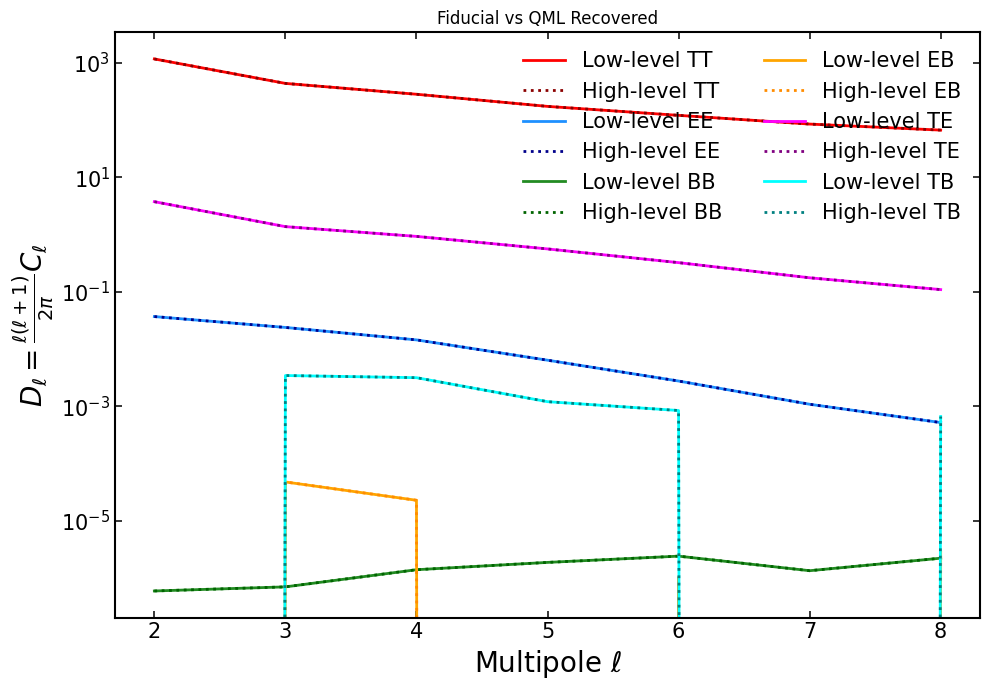

In [18]:
print("=== High-level power spectra ===")
print(f"High-level power shape: {high_lev_power_spectra.shape}")
print(f"High-level power first 5 values (sim 0): {high_lev_power_spectra[0, :5]}")

# Create diagnostic plots
fig, ax = plt.subplots()

# Define colors and labels
colors = ["red", "dodgerblue", "forestgreen", "orange", "magenta", "cyan"]
high_colors = ["darkred", "darkblue", "darkgreen", "darkorange", "purple", "teal"]

# Plot computed spectra for comparison
for ispec, spec_label in enumerate(spectra.collection.spectra_labels):
    start_idx = ispec * n_ell
    end_idx = (ispec + 1) * n_ell

    # Plot computed spectrum (average over simulations)
    computed = power_spectra[:, start_idx:end_idx].mean(axis=0)
    computed_test = high_lev_power_spectra[:, start_idx:end_idx].mean(axis=0)

    ell_mask = (ell >= 2) & (ell <= spectra.params.lmax)
    ell_plot = ell[ell_mask]

    ax.plot(
        ell_plot,
        computed,
        color=colors[ispec],
        label=f"Low-level {spec_label}",
        alpha=1,
    )
    ax.plot(
        ell_plot,
        computed_test,
        ":",
        color=high_colors[ispec],
        label=f"High-level {spec_label}",
        alpha=1,
    )

ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$D_\ell = \frac{{\ell(\ell+1)}}{{2π}}C_\ell$")
ax.set_title("Fiducial vs QML Recovered")
ax.legend(ncol=2)
ax.set_yscale("log")
plt.show()